# House Price Prediction and Explanation - Comprehensive Analysis
# Ames, Iowa Housing Dataset

**Author:** Data Science Team  
**Date:** November 2025  
**Objective:** Build interpretable machine learning models to predict house prices and provide actionable insights through comprehensive data analysis, feature engineering, and explainability visualizations.

---

## Table of Contents
11. [Model 1: Regularized Linear Regression](#section11)
12. [Model 2: Gradient Boosting](#section12)
13. [Model Evaluation](#section13)
14. [Global Explainability - Partial Dependence Plots (PDP)](#section14)
---

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
import xgboost as xgb
import joblib
import pickle

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("="*80)
print("LOADING DATA FROM NB1 CACHE")
print("="*80)

# Load processed data from NB1
cache_dir = Path('cache')

if not cache_dir.exists():
    print("\n❌ ERROR: Cache directory not found!")
    print("Please run NB1 first to generate the required data.")
    raise FileNotFoundError("Cache directory 'cache/' not found. Run NB1 first.")

# Load DataFrames
train_engineered = pd.read_pickle(cache_dir / 'train_engineered.pkl')
test_engineered = pd.read_pickle(cache_dir / 'test_engineered.pkl')
train_df = pd.read_pickle(cache_dir / 'train_df.pkl')
test_df = pd.read_pickle(cache_dir / 'test_df.pkl')

print("\n✓ Loaded DataFrames:")
print(f"  - train_engineered: {train_engineered.shape}")
print(f"  - test_engineered: {test_engineered.shape}")
print(f"  - train_df: {train_df.shape}")
print(f"  - test_df: {test_df.shape}")

# Load metadata
with open(cache_dir / 'nb1_metadata.pkl', 'rb') as f:
    nb1_metadata = pickle.load(f)

numeric_features = nb1_metadata['numeric_features']
categorical_features = nb1_metadata['categorical_features']
RANDOM_STATE = nb1_metadata['RANDOM_STATE']

print("\n✓ Loaded metadata:")
print(f"  - numeric_features: {len(numeric_features)} features")
print(f"  - categorical_features: {len(categorical_features)} features")
print(f"  - RANDOM_STATE: {RANDOM_STATE}")

np.random.seed(RANDOM_STATE)

print("\n" + "="*80)
print("DATA LOADED SUCCESSFULLY - READY FOR MODELING")
print("="*80)

LOADING DATA FROM NB1 CACHE

✓ Loaded DataFrames:
  - train_engineered: (1460, 179)
  - test_engineered: (1459, 178)
  - train_df: (1460, 83)
  - test_df: (1459, 80)

✓ Loaded metadata:
  - numeric_features: 36 features
  - categorical_features: 43 features
  - RANDOM_STATE: 42

DATA LOADED SUCCESSFULLY - READY FOR MODELING


<a id="section11"></a>
## 11. Model 1: Regularized Linear Regression (Elastic Net)

Build and tune an Elastic Net regression model with proper cross-validation.

In [5]:
# Prepare data for modeling
X_full = train_engineered.drop(['Id', 'SalePrice'], axis=1, errors='ignore')
y_full = train_engineered['SalePrice']
X_test_final = test_engineered.drop(['Id'], axis=1, errors='ignore')

# Ensure all columns are numeric
for col in X_full.select_dtypes(include=['object']).columns:
    X_full[col] = pd.to_numeric(X_full[col], errors='coerce').fillna(0)
for col in X_test_final.select_dtypes(include=['object']).columns:
    X_test_final[col] = pd.to_numeric(X_test_final[col], errors='coerce').fillna(0)

# Align train and test features
common_features = list(set(X_full.columns).intersection(set(X_test_final.columns)))
X_full = X_full[common_features]
X_test_final = X_test_final[common_features]

print(f"Final feature count: {len(common_features)}")
print(f"X_full shape: {X_full.shape}")
print(f"y_full shape: {y_full.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

# Apply log transformation to target (reduces skewness)
y_log = np.log1p(y_full)
print(f"\nTarget skewness before log transform: {y_full.skew():.4f}")
print(f"Target skewness after log transform: {y_log.skew():.4f}")

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X_full, y_log, test_size=0.2, random_state=RANDOM_STATE)

print(f"\nTrain set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")

# Feature scaling - RobustScaler (robust to outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_full_scaled = scaler.fit_transform(X_full)
X_test_scaled = scaler.transform(X_test_final)

print("\n✓ Data preparation complete")
print("✓ Feature scaling applied")

Final feature count: 177
X_full shape: (1460, 177)
y_full shape: (1460,)
X_test_final shape: (1459, 177)

Target skewness before log transform: 1.8829
Target skewness after log transform: 0.1213

Train set: (1168, 177)
Validation set: (292, 177)

✓ Data preparation complete
✓ Feature scaling applied


In [7]:
# Elastic Net Hyperparameter Tuning
print("="*80)
print("ELASTIC NET REGRESSION - HYPERPARAMETER TUNING")
print("="*80)

# Define parameter grid
elastic_params = {
    'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]  # 0=Ridge, 1=Lasso
}

# Grid search with cross-validation
elastic_net = ElasticNet(max_iter=10000, random_state=RANDOM_STATE)
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search_elastic = GridSearchCV(
    estimator=elastic_net,
    param_grid=elastic_params,
    scoring='neg_mean_squared_error',
    cv=kfold,
    n_jobs=-1,
    verbose=1
)

print("\nStarting Grid Search...")
grid_search_elastic.fit(X_train_scaled, y_train)

# Best parameters
print(f"\n{'='*80}")
print(f"BEST PARAMETERS")
print(f"{'='*80}")
print(f"Alpha: {grid_search_elastic.best_params_['alpha']}")
print(f"L1 Ratio: {grid_search_elastic.best_params_['l1_ratio']}")
print(f"Best CV Score (RMSE): {np.sqrt(-grid_search_elastic.best_score_):.4f}")

# Train final model with best parameters
best_elastic = grid_search_elastic.best_estimator_
best_elastic.fit(X_train_scaled, y_train)

# Predictions (in log scale)
y_train_pred_elastic_log = best_elastic.predict(X_train_scaled)
y_val_pred_elastic_log = best_elastic.predict(X_val_scaled)

# Convert back to original price scale
y_train_pred_elastic = np.expm1(y_train_pred_elastic_log)
y_val_pred_elastic = np.expm1(y_val_pred_elastic_log)
y_train_actual = np.expm1(y_train)
y_val_actual = np.expm1(y_val)

# Evaluation metrics (in original price scale)
train_rmse_elastic = np.sqrt(mean_squared_error(y_train_actual, y_train_pred_elastic))
val_rmse_elastic = np.sqrt(mean_squared_error(y_val_actual, y_val_pred_elastic))
train_mae_elastic = mean_absolute_error(y_train_actual, y_train_pred_elastic)
val_mae_elastic = mean_absolute_error(y_val_actual, y_val_pred_elastic)
train_r2_elastic = r2_score(y_train_actual, y_train_pred_elastic)
val_r2_elastic = r2_score(y_val_actual, y_val_pred_elastic)

print(f"\n{'='*80}")
print(f"ELASTIC NET PERFORMANCE")
print(f"{'='*80}")
print(f"Train RMSE: {train_rmse_elastic:.4f}")
print(f"Validation RMSE: {val_rmse_elastic:.4f}")
print(f"Train MAE: {train_mae_elastic:.4f}")
print(f"Validation MAE: {val_mae_elastic:.4f}")
print(f"Train R²: {train_r2_elastic:.4f}")
print(f"Validation R²: {val_r2_elastic:.4f}")

# Cross-validation scores
cv_scores_elastic = cross_val_score(best_elastic, X_full_scaled, y_log, cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1)

print("\n✓ Elastic Net model trained successfully")

cv_rmse_elastic = np.sqrt(-cv_scores_elastic)

print(f"\n5-Fold Cross-Validation RMSE: {cv_rmse_elastic.mean():.4f} (+/- {cv_rmse_elastic.std():.4f})")

ELASTIC NET REGRESSION - HYPERPARAMETER TUNING

Starting Grid Search...
Fitting 5 folds for each of 63 candidates, totalling 315 fits

BEST PARAMETERS
Alpha: 0.01
L1 Ratio: 0.1
Best CV Score (RMSE): 0.1416

ELASTIC NET PERFORMANCE
Train RMSE: 29783.8960
Validation RMSE: 27510.6489
Train MAE: 15618.0281
Validation MAE: 17018.8471
Train R²: 0.8513
Validation R²: 0.9013

✓ Elastic Net model trained successfully

5-Fold Cross-Validation RMSE: 0.1458 (+/- 0.0388)


<a id="section12"></a>
## 12. Model 2: Gradient Boosting (XGBoost)

Build and tune an XGBoost regression model with early stopping.

In [9]:
# XGBoost Hyperparameter Tuning
print("="*80)
print("XGBOOST REGRESSION - HYPERPARAMETER TUNING")
print("="*80)

# Define parameter grid
xgb_params = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'n_estimators': [500, 1000, 1500],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 1],  # L1 regularization
    'reg_lambda': [1, 5, 10]   # L2 regularization
}

# Create model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    tree_method='hist'
)

# Randomized search (faster than grid search for large parameter space)
from sklearn.model_selection import RandomizedSearchCV

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_params,
    n_iter=30,  # Number of parameter settings sampled
    scoring='neg_mean_squared_error',
    cv=kfold,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

print("\nStarting Randomized Search...")
random_search_xgb.fit(X_train, y_train)

# Best parameters
print(f"\n{'='*80}")
print(f"BEST PARAMETERS")
print(f"{'='*80}")
for param, value in random_search_xgb.best_params_.items():
    print(f"{param}: {value}")
print(f"Best CV Score (RMSE): {np.sqrt(-random_search_xgb.best_score_):.4f}")

# Train final model with best parameters and early stopping
best_xgb = xgb.XGBRegressor(
    **random_search_xgb.best_params_,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=RANDOM_STATE,
    tree_method='hist'
)

# Fit with early stopping
best_xgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Predictions (in log scale)
y_train_pred_xgb_log = best_xgb.predict(X_train)
y_val_pred_xgb_log = best_xgb.predict(X_val)

# Convert back to original price scale
y_train_pred_xgb = np.expm1(y_train_pred_xgb_log)
y_val_pred_xgb = np.expm1(y_val_pred_xgb_log)
# y_train_actual and y_val_actual already computed in Elastic Net section

# Evaluation metrics (in original price scale)
train_rmse_xgb = np.sqrt(mean_squared_error(y_train_actual, y_train_pred_xgb))
val_rmse_xgb = np.sqrt(mean_squared_error(y_val_actual, y_val_pred_xgb))
train_mae_xgb = mean_absolute_error(y_train_actual, y_train_pred_xgb)
val_mae_xgb = mean_absolute_error(y_val_actual, y_val_pred_xgb)
train_r2_xgb = r2_score(y_train_actual, y_train_pred_xgb)
val_r2_xgb = r2_score(y_val_actual, y_val_pred_xgb)

print(f"\n{'='*80}")
print(f"XGBOOST PERFORMANCE")
print(f"{'='*80}")
print(f"Train RMSE: {train_rmse_xgb:.4f}")
print(f"Validation RMSE: {val_rmse_xgb:.4f}")
print(f"Train MAE: {train_mae_xgb:.4f}")
print(f"Validation MAE: {val_mae_xgb:.4f}")
print(f"Train R²: {train_r2_xgb:.4f}")
print(f"Validation R²: {val_r2_xgb:.4f}")

# Cross-validation scores
cv_scores_xgb = cross_val_score(best_xgb, X_full, y_log, 
                                cv=kfold, scoring='neg_mean_squared_error', n_jobs=-1)

cv_rmse_xgb = np.sqrt(-cv_scores_xgb)

print("\n✓ XGBoost model trained successfully")


print(f"\n5-Fold Cross-Validation RMSE: {cv_rmse_xgb.mean():.4f} (+/- {cv_rmse_xgb.std():.4f})")

XGBOOST REGRESSION - HYPERPARAMETER TUNING

Starting Randomized Search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

BEST PARAMETERS
subsample: 0.8
reg_lambda: 10
reg_alpha: 0.1
n_estimators: 500
max_depth: 3
learning_rate: 0.05
colsample_bytree: 0.7
Best CV Score (RMSE): 0.1242

XGBOOST PERFORMANCE
Train RMSE: 12767.5446
Validation RMSE: 28027.7759
Train MAE: 7914.6595
Validation MAE: 15744.2088
Train R²: 0.9727
Validation R²: 0.8976

✓ XGBoost model trained successfully

5-Fold Cross-Validation RMSE: 0.1278 (+/- 0.0172)


In [ ]:
import joblib
import pickle
from pathlib import Path

# Create models directory if it doesn't exist
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

print("="*80)
print("SAVING TRAINED MODELS AND PREPROCESSING OBJECTS")
print("="*80)

# Save XGBoost model
xgb_path = models_dir / 'xgboost_model.pkl'
joblib.dump(best_xgb, xgb_path)
print(f"\n✓ XGBoost model saved to: {xgb_path}")

# Save Elastic Net model
elastic_path = models_dir / 'elastic_net_model.pkl'
joblib.dump(best_elastic, elastic_path)
print(f"✓ Elastic Net model saved to: {elastic_path}")

# Save the scaler (used for Elastic Net)
scaler_path = models_dir / 'scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved to: {scaler_path}")

# Save feature names for reference
feature_info = {
    'feature_names': X_full.columns.tolist(),
    'n_features': len(X_full.columns),
    'target_transformation': 'log1p'  # Important to remember for inverse transform
}
feature_info_path = models_dir / 'feature_info.pkl'
joblib.dump(feature_info, feature_info_path)
print(f"✓ Feature information saved to: {feature_info_path}")

# Save best parameters for reference
model_params = {
    'xgboost_params': best_xgb.get_params(),
    'elastic_net_params': best_elastic.get_params(),
    'xgb_cv_rmse': f"{cv_rmse_xgb.mean():.4f} (+/- {cv_rmse_xgb.std():.4f})",
    'elastic_cv_rmse': f"{cv_rmse_elastic.mean():.4f} (+/- {cv_rmse_elastic.std():.4f})"
}
params_path = models_dir / 'model_parameters.pkl'
joblib.dump(model_params, params_path)
print(f"✓ Model parameters saved to: {params_path}")

print("\n" + "="*80)
print("ALL MODELS AND OBJECTS SAVED SUCCESSFULLY")
print("="*80)
print(f"\nSaved files in '{models_dir}' directory:")
print(f"  1. xgboost_model.pkl        - Trained XGBoost model")
print(f"  2. elastic_net_model.pkl    - Trained Elastic Net model")
print(f"  3. scaler.pkl               - StandardScaler for Elastic Net")
print(f"  4. feature_info.pkl         - Feature names and metadata")
print(f"  5. model_parameters.pkl     - Model hyperparameters and metrics")

SAVING TRAINED MODELS AND PREPROCESSING OBJECTS

✓ XGBoost model saved to: models\xgboost_model.pkl
✓ Elastic Net model saved to: models\elastic_net_model.pkl
✓ Scaler saved to: models\scaler.pkl
✓ Feature information saved to: models\feature_info.pkl
✓ Model parameters saved to: models\model_parameters.pkl

ALL MODELS AND OBJECTS SAVED SUCCESSFULLY

Saved files in 'models' directory:
  1. xgboost_model.pkl        - Trained XGBoost model
  2. elastic_net_model.pkl    - Trained Elastic Net model
  3. scaler.pkl               - StandardScaler for Elastic Net
  4. feature_info.pkl         - Feature names and metadata
  5. model_parameters.pkl     - Model hyperparameters and metrics


<a id="section13"></a>
## 13. Model Evaluation and Comparison

Compare both models using multiple metrics and residual analysis.

MODEL COMPARISON
      Model   Train_RMSE     Val_RMSE    Train_MAE      Val_MAE  Train_R2   Val_R2
Elastic Net 29783.895992 27510.648873 15618.028095 17018.847090  0.851275 0.901329
    XGBoost 12767.544586 28027.775913  7914.659517 15744.208757  0.972670 0.897585


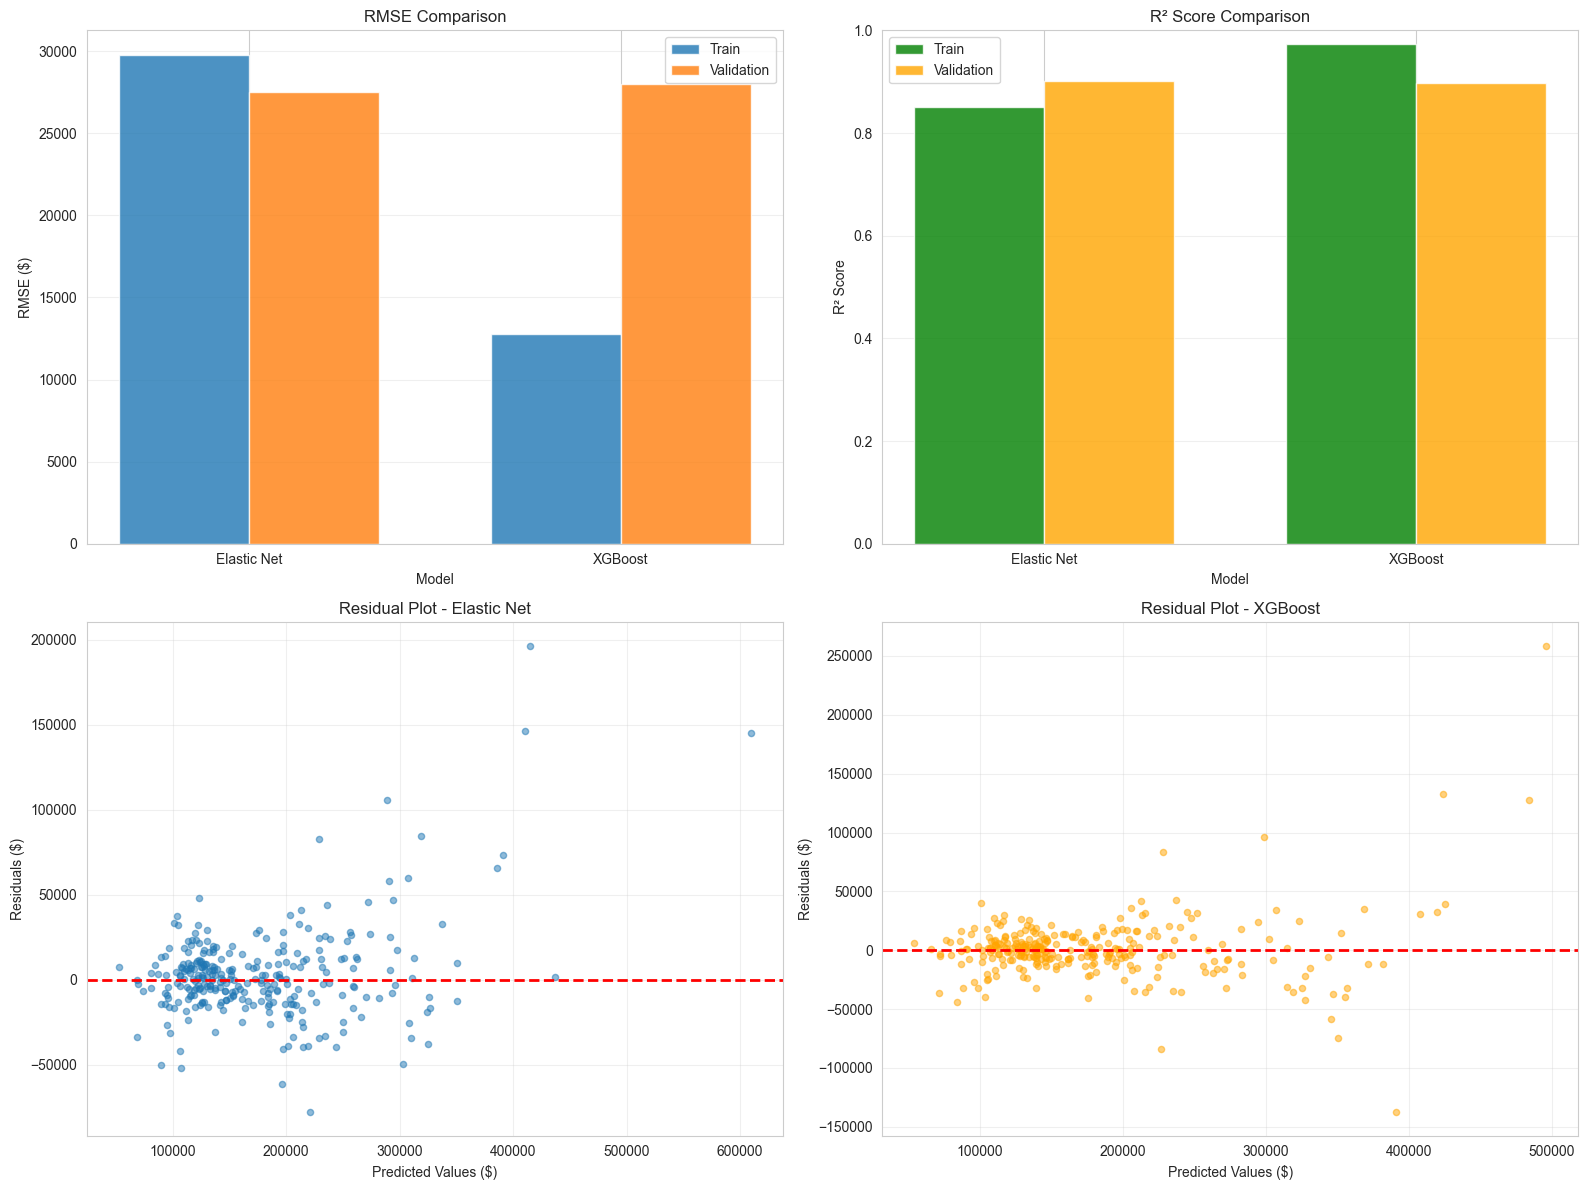

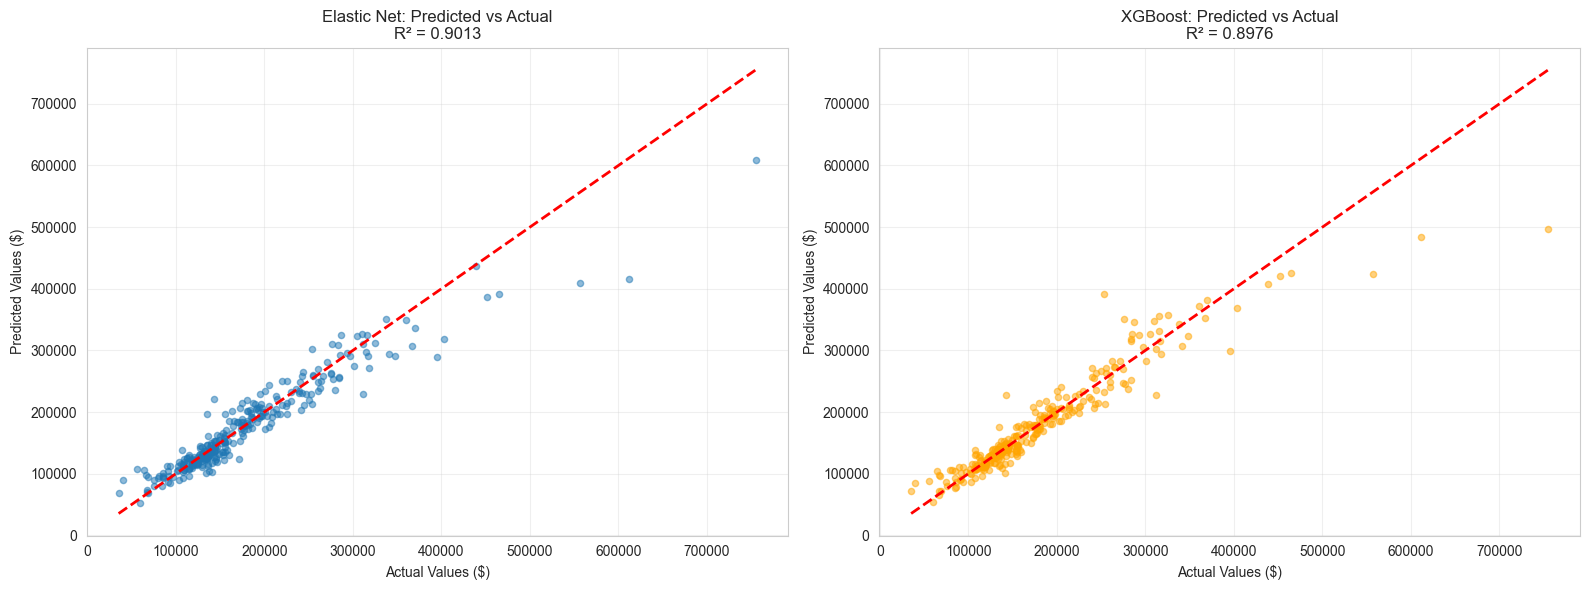


BEST MODEL: Elastic Net
✓ Model evaluation complete


In [10]:
# Model Comparison
comparison_df = pd.DataFrame({
    'Model': ['Elastic Net', 'XGBoost'],
    'Train_RMSE': [train_rmse_elastic, train_rmse_xgb],
    'Val_RMSE': [val_rmse_elastic, val_rmse_xgb],
    'Train_MAE': [train_mae_elastic, train_mae_xgb],
    'Val_MAE': [val_mae_elastic, val_mae_xgb],
    'Train_R2': [train_r2_elastic, train_r2_xgb],
    'Val_R2': [val_r2_elastic, val_r2_xgb]
})

print("="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. RMSE Comparison
ax1 = axes[0, 0]
x_pos = np.arange(len(comparison_df))
width = 0.35
ax1.bar(x_pos - width/2, comparison_df['Train_RMSE'], width, label='Train', alpha=0.8)
ax1.bar(x_pos + width/2, comparison_df['Val_RMSE'], width, label='Validation', alpha=0.8)
ax1.set_xlabel('Model')
ax1.set_ylabel('RMSE ($)')
ax1.set_title('RMSE Comparison')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_df['Model'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. R² Comparison
ax2 = axes[0, 1]
ax2.bar(x_pos - width/2, comparison_df['Train_R2'], width, label='Train', alpha=0.8, color='green')
ax2.bar(x_pos + width/2, comparison_df['Val_R2'], width, label='Validation', alpha=0.8, color='orange')
ax2.set_xlabel('Model')
ax2.set_ylabel('R² Score')
ax2.set_title('R² Score Comparison')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison_df['Model'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1])

# 3. Residual Plot - Elastic Net
ax3 = axes[1, 0]
residuals_elastic = y_val_actual - y_val_pred_elastic
ax3.scatter(y_val_pred_elastic, residuals_elastic, alpha=0.5, s=20)
ax3.axhline(color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted Values ($)')
ax3.set_ylabel('Residuals ($)')
ax3.set_title('Residual Plot - Elastic Net')
ax3.grid(alpha=0.3)

# 4. Residual Plot - XGBoost
ax4 = axes[1, 1]
residuals_xgb = y_val_actual - y_val_pred_xgb
ax4.scatter(y_val_pred_xgb, residuals_xgb, alpha=0.5, s=20, color='orange')
ax4.axhline(color='r', linestyle='--', linewidth=2)
ax4.set_xlabel('Predicted Values ($)')
ax4.set_ylabel('Residuals ($)')
ax4.set_title('Residual Plot - XGBoost')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Predicted vs Actual plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elastic Net
ax1 = axes[0]
ax1.scatter(y_val_actual, y_val_pred_elastic, alpha=0.5, s=20)
ax1.plot([y_val_actual.min(), y_val_actual.max()], [y_val_actual.min(), y_val_actual.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Values ($)')
ax1.set_ylabel('Predicted Values ($)')
ax1.set_title(f'Elastic Net: Predicted vs Actual\nR² = {val_r2_elastic:.4f}')
ax1.grid(alpha=0.3)

# XGBoost
ax2 = axes[1]
ax2.scatter(y_val_actual, y_val_pred_xgb, alpha=0.5, s=20, color='orange')
ax2.plot([y_val_actual.min(), y_val_actual.max()], [y_val_actual.min(), y_val_actual.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Values ($)')
ax2.set_ylabel('Predicted Values ($)')
ax2.set_title(f'XGBoost: Predicted vs Actual\nR² = {val_r2_xgb:.4f}')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Determine best model
best_model_name = comparison_df.loc[comparison_df['Val_RMSE'].idxmin(), 'Model']
print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*80}")
print(f"✓ Model evaluation complete")

<a id="section14"></a>
## 14. Global Explainability - Partial Dependence Plots (PDP)

Understand global feature importance and relationships using multiple methods.

PARTIAL DEPENDENCE PLOTS - GLOBAL EXPLAINABILITY

Top 15 Features - XGBoost Importance:
               Feature  Importance
74         OverallQual    0.151657
20             TotalSF    0.114898
159        KitchenQual    0.104875
48          GarageCars    0.061816
154       GarageFinish    0.049004
70        CentralAir_Y    0.044942
64           TotalBath    0.038508
79         FireplaceQu    0.029467
124       KitchenAbvGr    0.024670
13            BsmtQual    0.021737
174         GarageCond    0.021414
66       Alley_Missing    0.017989
170  GarageType_Attchd    0.017205
88   YearsSinceRemodel    0.016685
173         GarageQual    0.015880


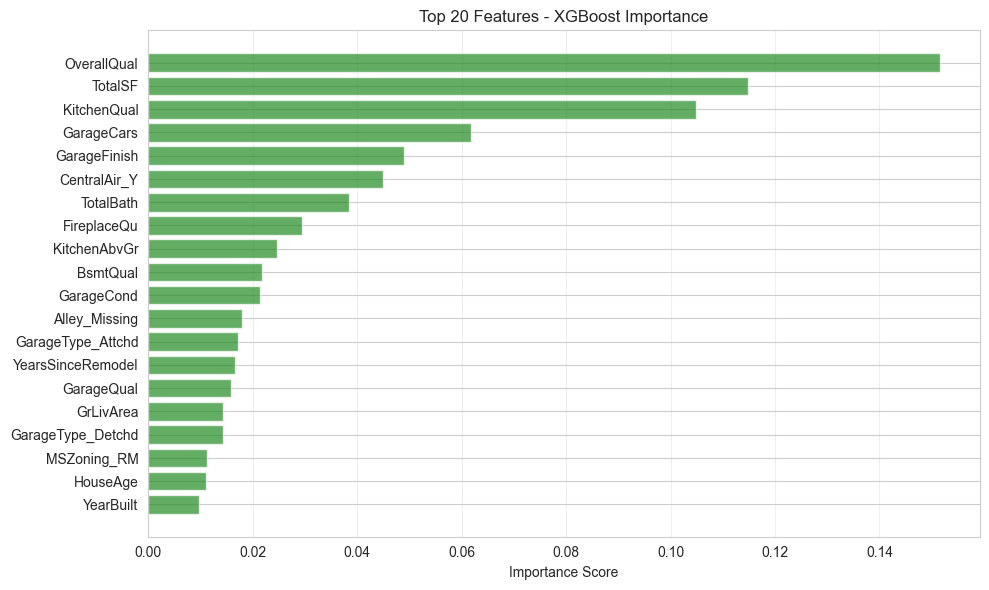

In [11]:
print("="*80)
print("PARTIAL DEPENDENCE PLOTS - GLOBAL EXPLAINABILITY")
print("="*80)

# Get top features from XGBoost
xgb_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Features - XGBoost Importance:")
print(xgb_feature_importance.head(15))

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_20 = xgb_feature_importance.head(20)
plt.barh(range(len(top_20)), top_20['Importance'], color='forestgreen', alpha=0.7)
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Importance Score')
plt.title('Top 20 Features - XGBoost Importance')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Generating Partial Dependence Plots for top 8 features...


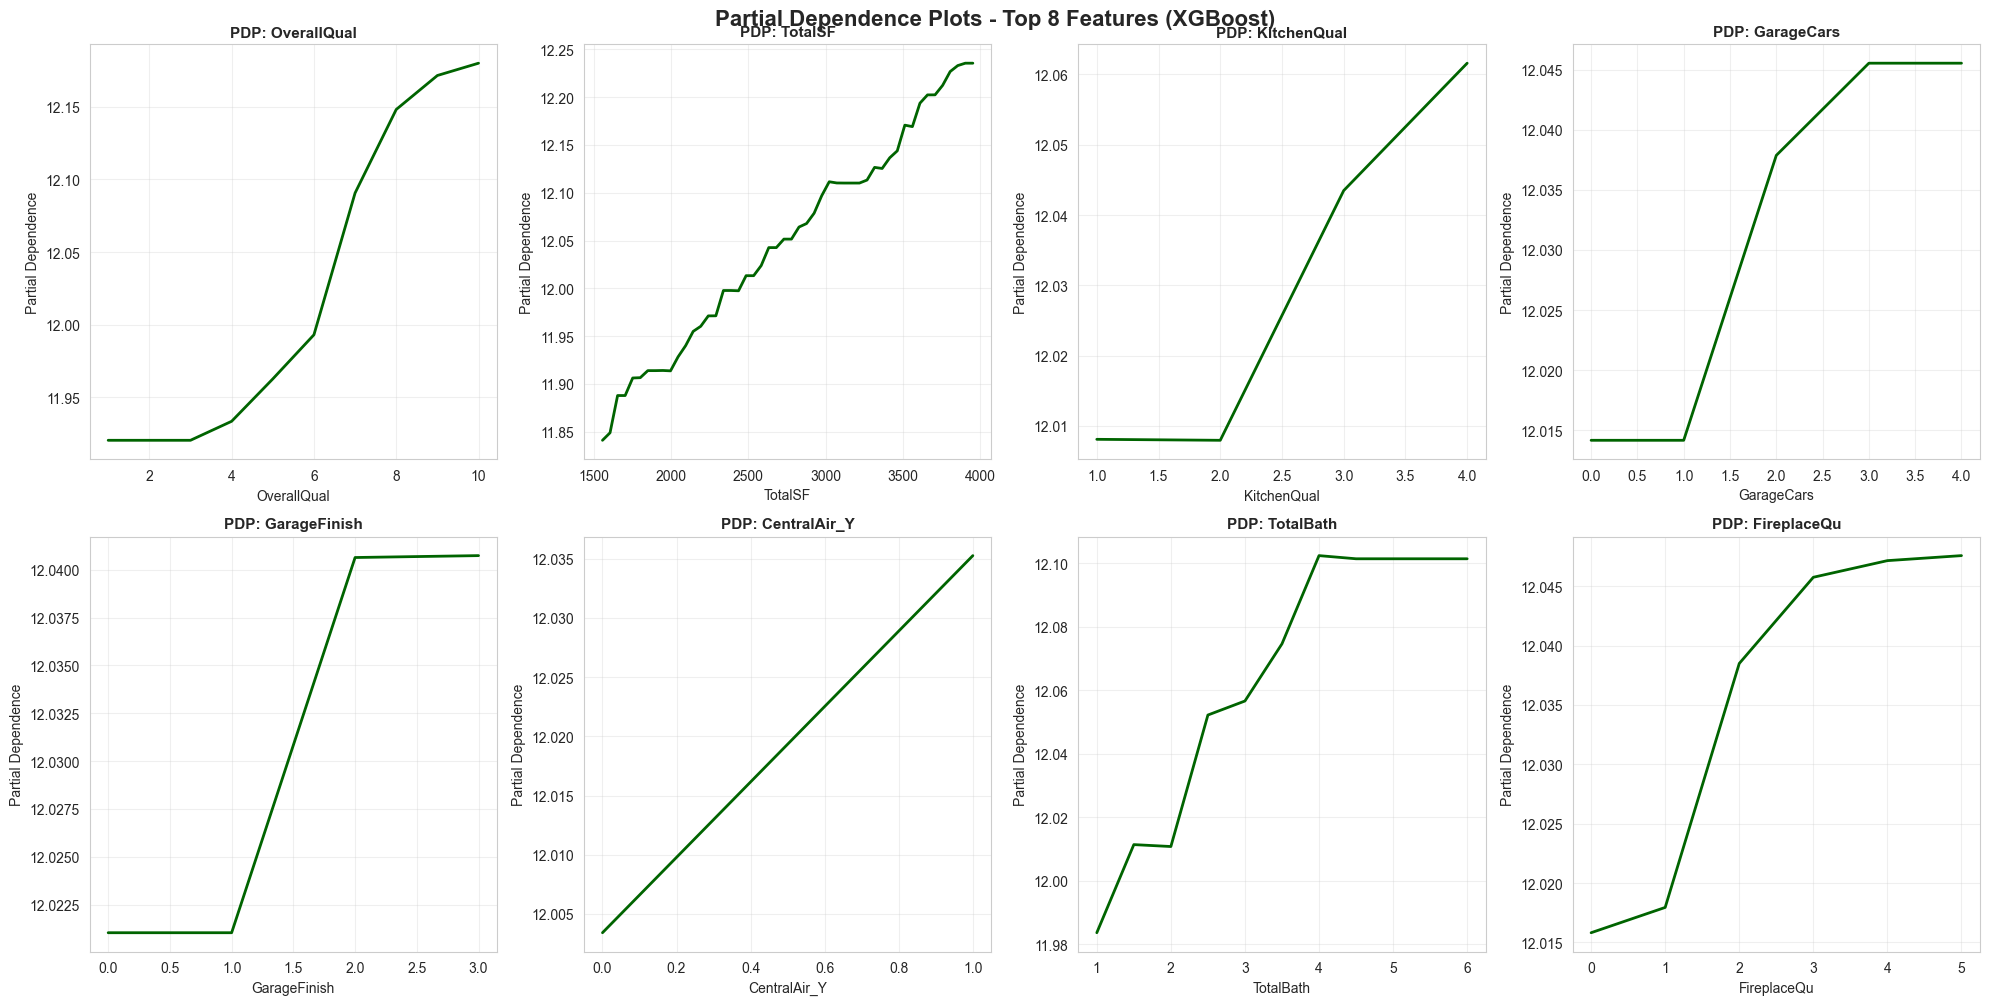

✓ 1-way Partial Dependence Plots generated


In [12]:
# Create 1-way PDPs for top features
top_features_for_pdp = xgb_feature_importance.head(8)['Feature'].tolist()
feature_indices = [X_train.columns.get_loc(feat) for feat in top_features_for_pdp]

print(f"\nGenerating Partial Dependence Plots for top 8 features...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (feature_idx, feature_name) in enumerate(zip(feature_indices, top_features_for_pdp)):
    pd_result = partial_dependence(
        best_xgb, 
        X_train, 
        features=[feature_idx],
        grid_resolution=50
    )
    
    ax = axes[idx]
    ax.plot(pd_result['grid_values'][0], pd_result['average'][0], linewidth=2, color='darkgreen')
    ax.set_xlabel(feature_name, fontsize=10)
    ax.set_ylabel('Partial Dependence', fontsize=10)
    ax.set_title(f'PDP: {feature_name}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Partial Dependence Plots - Top 8 Features (XGBoost)', 
             fontsize=16, fontweight='bold', y=1.001)
plt.show()

print("✓ 1-way Partial Dependence Plots generated")


Generating 2-way interaction plots...


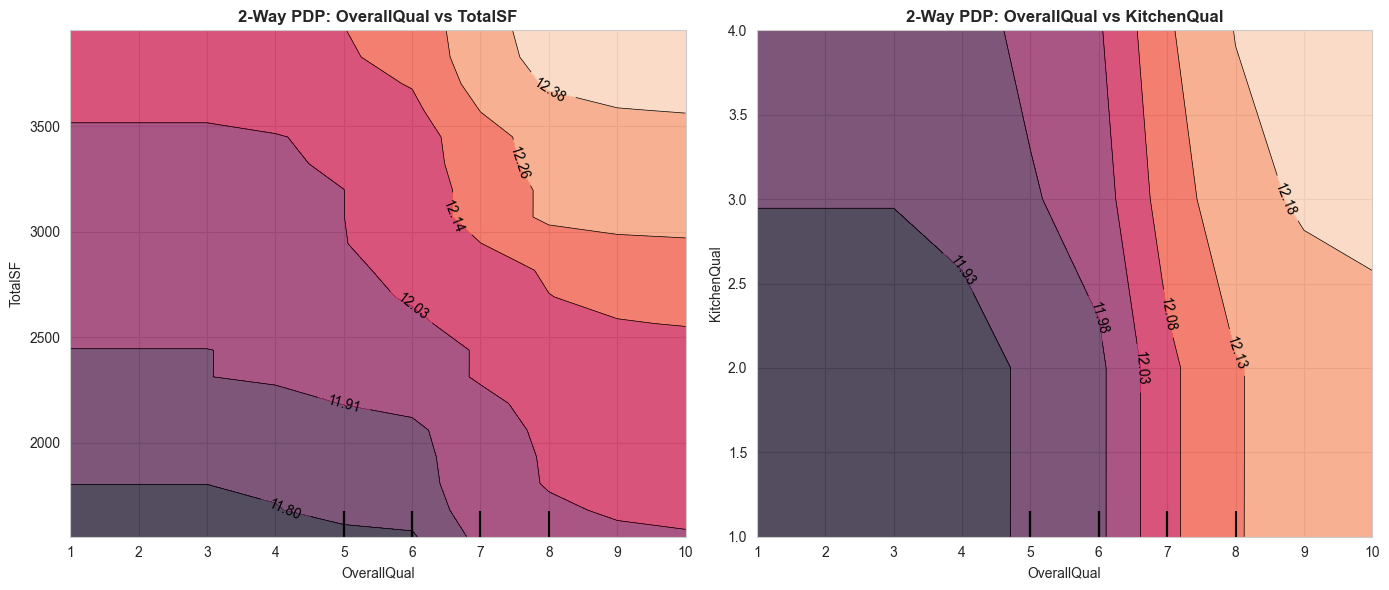

✓ 2-way Partial Dependence Plots generated

NOTEBOOK 1 COMPLETE

Next Steps:
  - Use Notebook 2 for single case inference with SHAP analysis
  - Use Notebook 3 to generate predictions for the entire test set


In [13]:
# Create 2-way interaction PDPs
print("\nGenerating 2-way interaction plots...")

top_4_features = xgb_feature_importance.head(4)['Feature'].tolist()
top_4_indices = [X_train.columns.get_loc(feat) for feat in top_4_features]

feature_pairs = [
    (top_4_indices[0], top_4_indices[1]),
    (top_4_indices[0], top_4_indices[2])
]

pair_names = [
    f"{top_4_features[0]} vs {top_4_features[1]}",
    f"{top_4_features[0]} vs {top_4_features[2]}"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

for idx, (feature_pair, pair_name) in enumerate(zip(feature_pairs, pair_names)):
    display = PartialDependenceDisplay.from_estimator(
        best_xgb,
        X_train,
        features=[feature_pair],
        grid_resolution=20,
        ax=axes[idx]
    )
    axes[idx].set_title(f'2-Way PDP: {pair_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ 2-way Partial Dependence Plots generated")
print("\n" + "="*80)
print("NOTEBOOK 1 COMPLETE")
print("="*80)
print("\nNext Steps:")
print("  - Use Notebook 2 for single case inference with SHAP analysis")
print("  - Use Notebook 3 to generate predictions for the entire test set")


ELASTIC NET - FEATURE IMPORTANCE

Top 15 Features - Elastic Net Absolute Coefficients:
              Feature  Coefficient
74        OverallQual     0.118831
136      TotRmsAbvGrd     0.111104
47        AreaPerRoom     0.104822
48         GarageCars     0.052197
30    Condition1_Norm     0.049899
133       MSZoning_RM     0.045112
25        OverallCond     0.038156
90    BsmtFinishRatio     0.038024
148        Functional     0.035951
58   Foundation_PConc     0.034622
79        FireplaceQu     0.030305
105        MSSubClass     0.030156
103       Has2ndFloor     0.029323
70       CentralAir_Y     0.028789
156          HouseAge     0.028525


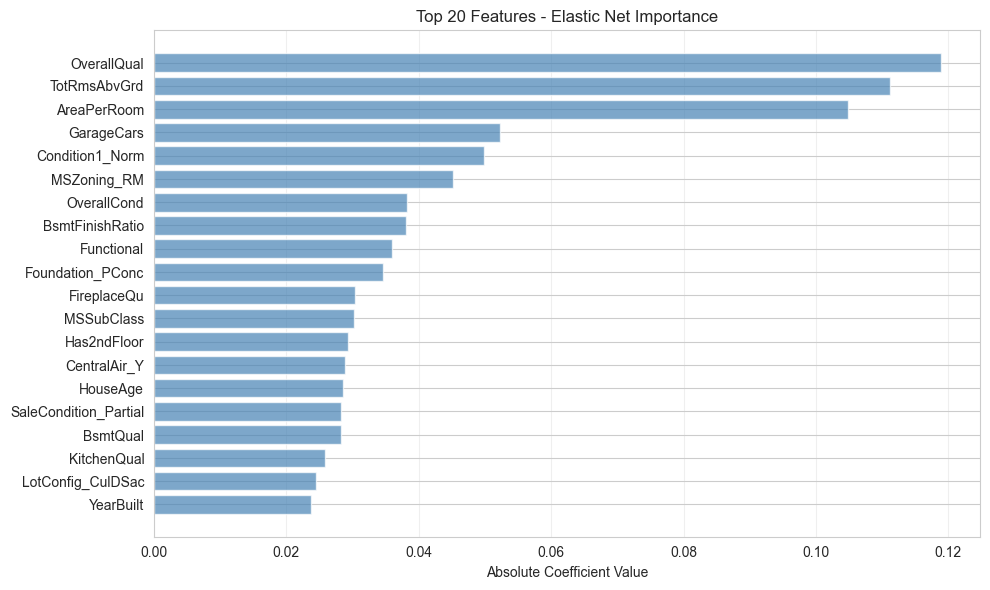

✓ Elastic Net feature importance calculated


In [14]:
# Elastic Net Feature Importance (from coefficients)
print("\n" + "="*80)
print("ELASTIC NET - FEATURE IMPORTANCE")
print("="*80)

elastic_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': np.abs(best_elastic.coef_)
}).sort_values('Coefficient', ascending=False)

print("\nTop 15 Features - Elastic Net Absolute Coefficients:")
print(elastic_coef.head(15))

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_20_elastic = elastic_coef.head(20)
plt.barh(range(len(top_20_elastic)), top_20_elastic['Coefficient'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top_20_elastic)), top_20_elastic['Feature'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Top 20 Features - Elastic Net Importance')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Elastic Net feature importance calculated")


Generating Partial Dependence Plots for Elastic Net top 8 features...


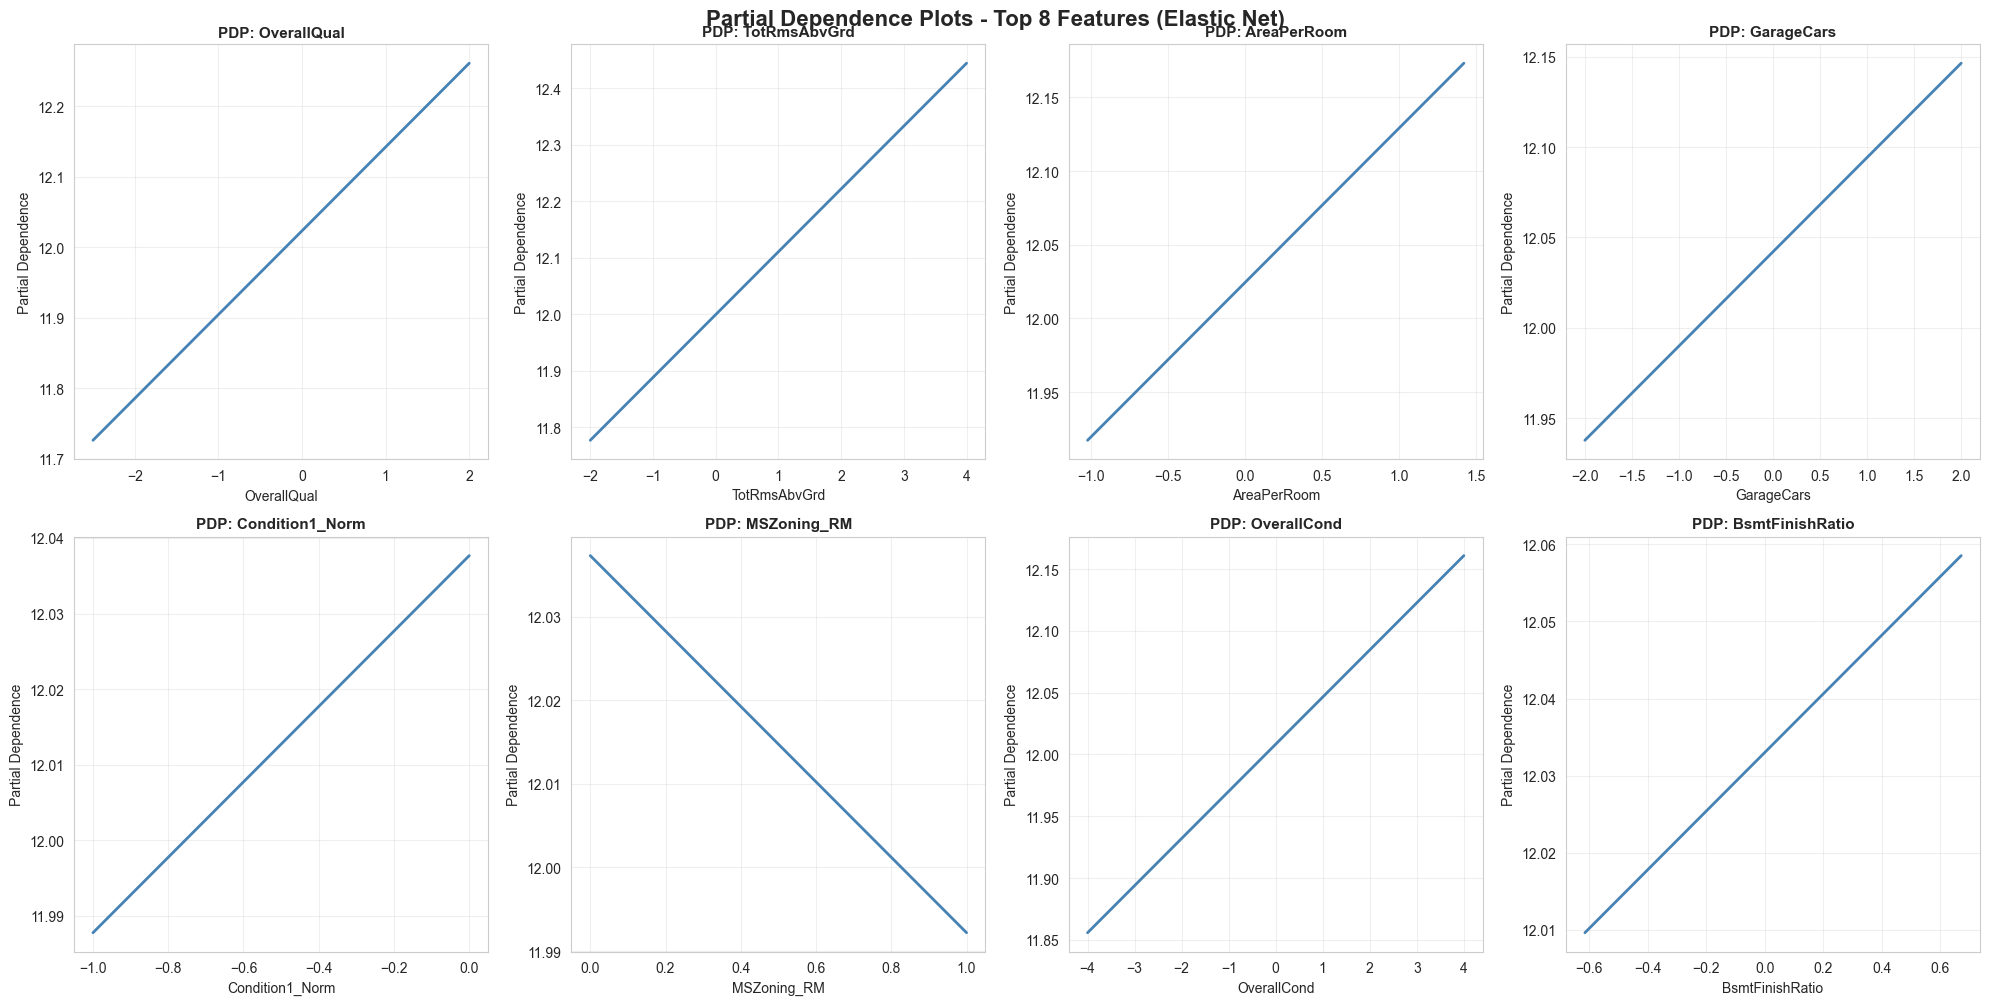

✓ Elastic Net 1-way Partial Dependence Plots generated


In [15]:
# Create 1-way PDPs for Elastic Net top features
top_features_elastic = elastic_coef.head(8)['Feature'].tolist()
feature_indices_elastic = [X_train.columns.get_loc(feat) for feat in top_features_elastic]

print(f"\nGenerating Partial Dependence Plots for Elastic Net top 8 features...")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (feature_idx, feature_name) in enumerate(zip(feature_indices_elastic, top_features_elastic)):
    pd_result = partial_dependence(
        best_elastic, 
        X_train_scaled,  # Use scaled data for Elastic Net
        features=[feature_idx],
        grid_resolution=50
    )
    
    ax = axes[idx]
    ax.plot(pd_result['grid_values'][0], pd_result['average'][0], linewidth=2, color='steelblue')
    ax.set_xlabel(feature_name, fontsize=10)
    ax.set_ylabel('Partial Dependence', fontsize=10)
    ax.set_title(f'PDP: {feature_name}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Partial Dependence Plots - Top 8 Features (Elastic Net)', 
             fontsize=16, fontweight='bold', y=1.001)
plt.show()

print("✓ Elastic Net 1-way Partial Dependence Plots generated")


Generating Elastic Net 2-way interaction plots...


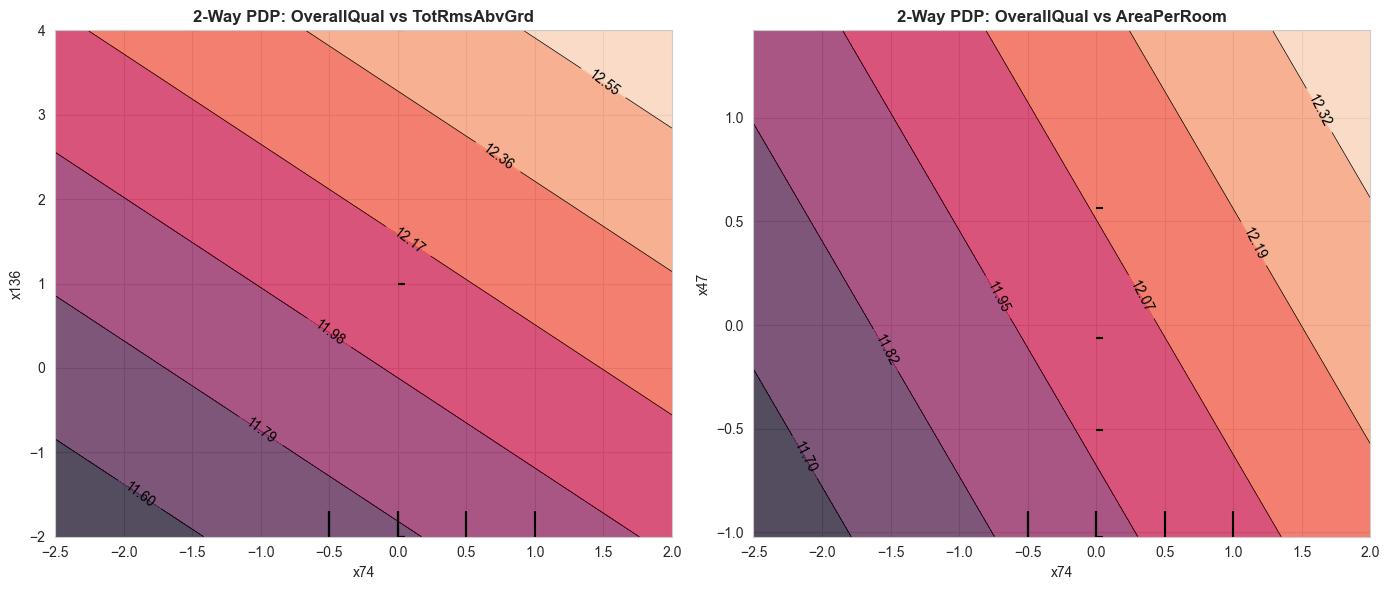

✓ Elastic Net 2-way Partial Dependence Plots generated


In [16]:
# Create 2-way interaction PDPs for Elastic Net
print("\nGenerating Elastic Net 2-way interaction plots...")

top_4_features_elastic = elastic_coef.head(4)['Feature'].tolist()
top_4_indices_elastic = [X_train.columns.get_loc(feat) for feat in top_4_features_elastic]

feature_pairs_elastic = [
    (top_4_indices_elastic[0], top_4_indices_elastic[1]),
    (top_4_indices_elastic[0], top_4_indices_elastic[2])
]

pair_names_elastic = [
    f"{top_4_features_elastic[0]} vs {top_4_features_elastic[1]}",
    f"{top_4_features_elastic[0]} vs {top_4_features_elastic[2]}"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes = axes.flatten()

for idx, (feature_pair, pair_name) in enumerate(zip(feature_pairs_elastic, pair_names_elastic)):
    display = PartialDependenceDisplay.from_estimator(
        best_elastic,
        X_train_scaled,  # Use scaled data for Elastic Net
        features=[feature_pair],
        grid_resolution=20,
        ax=axes[idx]
    )
    axes[idx].set_title(f'2-Way PDP: {pair_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Elastic Net 2-way Partial Dependence Plots generated")

---
## Save Outputs for NB3

Save trained models and validation data to cache folder for use in NB3.

In [17]:
print("="*80)
print("SAVING NB2 OUTPUTS TO CACHE")
print("="*80)

# Save trained models to cache (in addition to models/ directory)
cache_dir = Path('cache')

# Save models
joblib.dump(best_xgb, cache_dir / 'best_xgb.pkl')
joblib.dump(best_elastic, cache_dir / 'best_elastic.pkl')
joblib.dump(scaler, cache_dir / 'scaler.pkl')

print("\n✓ Saved trained models:")
print("  - best_xgb.pkl")
print("  - best_elastic.pkl")
print("  - scaler.pkl")

# Save train/validation splits and features
X_train.to_pickle(cache_dir / 'X_train.pkl')
X_val.to_pickle(cache_dir / 'X_val.pkl')
y_train.to_pickle(cache_dir / 'y_train.pkl')
y_val.to_pickle(cache_dir / 'y_val.pkl')
X_full.to_pickle(cache_dir / 'X_full.pkl')
y_log.to_pickle(cache_dir / 'y_log.pkl')

# Save test data for submission in nb4
pd.DataFrame(X_test_final).to_pickle(cache_dir / 'X_test_final.pkl')
pd.DataFrame(X_test_scaled, columns=X_test_final.columns).to_pickle(cache_dir / 'X_test_scaled.pkl')

print("\n✓ Saved train/validation data:")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_val: {X_val.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_val: {y_val.shape}")
print(f"  - X_full: {X_full.shape}")
print(f"  - y_log: {y_log.shape}")

print("\n✓ Saved test data for submission:")
print(f"  - X_test_final: {X_test_final.shape}")
print(f"  - X_test_scaled: {X_test_scaled.shape}")

# Save common_features list
nb2_metadata = {
    'common_features': common_features,
    'cv_rmse_xgb': cv_rmse_xgb,
    'cv_rmse_elastic': cv_rmse_elastic,
    'train_rmse_xgb': train_rmse_xgb,
    'val_rmse_xgb': val_rmse_xgb,
    'train_rmse_elastic': train_rmse_elastic,
    'val_rmse_elastic': val_rmse_elastic
}

with open(cache_dir / 'nb2_metadata.pkl', 'wb') as f:
    pickle.dump(nb2_metadata, f)

print("\n✓ Saved metadata:")
print(f"  - common_features: {len(common_features)} features")
print(f"  - Model performance metrics")

print("\n" + "="*80)
print("NB2 COMPLETE - OUTPUTS SAVED TO CACHE/")
print("="*80)
print("\n➡️  Next: Run NB3 for SHAP analysis and predictions")

SAVING NB2 OUTPUTS TO CACHE

✓ Saved trained models:
  - best_xgb.pkl
  - best_elastic.pkl
  - scaler.pkl

✓ Saved train/validation data:
  - X_train: (1168, 177)
  - X_val: (292, 177)
  - y_train: (1168,)
  - y_val: (292,)
  - X_full: (1460, 177)
  - y_log: (1460,)

✓ Saved test data for submission:
  - X_test_final: (1459, 177)
  - X_test_scaled: (1459, 177)

✓ Saved metadata:
  - common_features: 177 features
  - Model performance metrics

NB2 COMPLETE - OUTPUTS SAVED TO CACHE/

➡️  Next: Run NB3 for SHAP analysis and predictions
